# Opinion dynamics simulation: patched 2×2 comparison

This notebook compares opinion dynamics across two modeling dimensions:

1. **Opinion space**: discrete vs continuous
2. **Interaction structure**: non-graph vs graph-based

The core comparison is:

| | Non-graph-based | Graph-based |
|---|---|---|
| **Discrete** | Discrete mean-field model | Discrete graph voter model |
| **Continuous** | Continuous bounded-confidence model | Recommender-weighted graph model |

The recommender-weighted graph model is the main contribution. It adds human-behavior variables and allows comparison across multiple simulated recommender algorithms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Reproducibility
np.random.seed(42)

# Global simulation parameters
N = 100          # number of agents
T = 50           # number of time steps
mu = 0.25        # influence strength
epsilon = 0.35   # bounded confidence threshold
beta = 6.0       # recommender similarity/diversity strength
p_edge = 0.08    # graph edge probability

## 1. Initial conditions

Discrete models use binary opinions:

\[
s_i(t) \in \{-1,+1\}
\]

Continuous models use opinions in:

\[
s_i(t) \in [-1,1]
\]

The continuous model can be initialized using a uniform, normal, or bimodal distribution. The **bimodal** distribution is useful for testing whether models preserve, reduce, or amplify polarization.

In [2]:
def initialize_discrete_opinions(N, p_positive=0.5):
    """
    Creates binary opinions in {-1, +1}.
    p_positive controls the initial proportion of +1 opinions.
    """
    return np.random.choice([-1, 1], size=N, p=[1 - p_positive, p_positive])


def initialize_continuous_opinions(N, distribution="bimodal"):
    """
    Creates continuous opinions in [-1, 1].

    distribution options:
    - uniform: opinions spread evenly across [-1, 1]
    - normal: opinions concentrated near 0
    - bimodal: two polarized initial clusters
    """
    if distribution == "uniform":
        opinions = np.random.uniform(-1, 1, N)

    elif distribution == "normal":
        opinions = np.random.normal(0, 0.35, N)

    elif distribution == "bimodal":
        group1 = np.random.normal(-0.6, 0.15, N // 2)
        group2 = np.random.normal(0.6, 0.15, N - N // 2)
        opinions = np.concatenate([group1, group2])
        np.random.shuffle(opinions)

    else:
        raise ValueError("distribution must be 'uniform', 'normal', or 'bimodal'")

    return np.clip(opinions, -1, 1)

## 2. Agent-level human behavior traits

The recommender model includes heterogeneous agents. This makes the model more realistic than treating every agent as identical.

- **susceptibility**: how open an agent is to influence
- **stubbornness**: how strongly an agent is anchored to their initial opinion
- **activity**: how likely the agent is to update at a given time step
- **extremity_bias**: how strongly the agent may move toward a more extreme version of their current opinion

In [3]:
def initialize_agent_traits(N):
    """
    Creates heterogeneous agent-level traits.
    These are only used in the recommender-weighted graph model.
    """
    traits = {
        # Mostly low/moderate openness, with a few highly influenceable agents
        "susceptibility": np.random.beta(2, 5, N),

        # Resistance to change / anchoring to original opinion
        "stubbornness": np.random.beta(2, 6, N),

        # Not everyone updates every time step
        "activity": np.random.uniform(0.6, 1.0, N),

        # Tendency toward more extreme current opinion
        "extremity_bias": np.random.beta(2, 8, N)
    }
    return traits

## 3. Graph generation

The graph-based models use an Erdős–Rényi random graph. The code regenerates the graph until it is connected, so every node can potentially be affected by the network.

In [4]:
def create_graph(N, p=0.08):
    """
    Creates a connected undirected Erdős–Rényi graph.
    p controls the probability of an edge between two nodes.
    """
    G = nx.erdos_renyi_graph(N, p, seed=42)

    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(N, p, seed=np.random.randint(10000))

    return G


def plot_graph(G, opinions=None, title="Social network"):
    """
    Optional graph visualization. If opinions are passed, node colors correspond to opinions.
    """
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G, seed=42)

    if opinions is None:
        nx.draw(G, pos, node_size=60, alpha=0.75, with_labels=False)
    else:
        nx.draw(
            G,
            pos,
            node_color=opinions,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            node_size=70,
            alpha=0.85,
            with_labels=False
        )
        sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=-1, vmax=1))
        plt.colorbar(sm, label="Opinion")

    plt.title(title)
    plt.show()

## 4. Model 1: discrete non-graph mean-field model

This is the simplest theoretical baseline. Agents hold binary opinions and update according to the overall population distribution, not a graph.

\[
\mathcal{O}=\{-1,+1\}
\]

If 70% of the population is \(+1\), then each agent has a 70% chance of becoming \(+1\) at the next time step.

In [5]:
def run_discrete_mean_field(s0, T):
    """
    Discrete non-graph model.
    Each agent samples their next opinion from the global population distribution.
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()

    for t in range(T):
        p_positive = np.mean(s == 1)
        s = np.random.choice([-1, 1], size=N, p=[1 - p_positive, p_positive])
        history[t + 1] = s.copy()

    return history

## 5. Model 2: discrete graph voter model

This is the graph-based discrete baseline. Each node copies the opinion of a randomly selected neighbor.

\[
s_i(t+1)=s_j(t), \quad j\in N_i
\]

In [6]:
def run_discrete_voter_graph(G, s0, T):
    """
    Discrete graph-based voter model.
    Each node copies the opinion of a randomly selected neighbor.
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()

    for t in range(T):
        new_s = s.copy()

        for i in range(N):
            neighbors = list(G.neighbors(i))
            if len(neighbors) > 0:
                chosen_neighbor = np.random.choice(neighbors)
                new_s[i] = s[chosen_neighbor]

        s = new_s
        history[t + 1] = s.copy()

    return history

## 6. Model 3: continuous non-graph bounded-confidence model

This replaces the overly simple continuous mean-field model. Agents are not pulled toward the global mean. Instead, they only respond to agents whose opinions are within a confidence threshold.

\[
|s_i(t)-s_j(t)| \leq \epsilon
\]

There is no graph, so every agent can potentially influence every other agent, but only if their opinions are close enough.

In [7]:
def run_continuous_bounded_confidence_non_graph(s0, T, mu=0.2, epsilon=0.4):
    """
    Continuous non-graph bounded-confidence model.
    Each agent is influenced by all other agents whose opinions are within epsilon.
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()

    for t in range(T):
        new_s = s.copy()

        for i in range(N):
            distances = np.abs(s - s[i])
            close_agents = distances <= epsilon
            close_agents[i] = False  # exclude self

            if np.any(close_agents):
                local_mean = np.mean(s[close_agents])
                new_s[i] = s[i] + mu * (local_mean - s[i])

        s = np.clip(new_s, -1, 1)
        history[t + 1] = s.copy()

    return history

## 7. Recommender algorithms

The graph-based continuous model can use several simulated recommender algorithms:

- **similarity**: recommends similar opinions
- **diversity**: recommends different opinions
- **popularity**: recommends high-degree/high-visibility nodes
- **engagement**: recommends similar and extreme content
- **mixed**: mostly similarity-based, with some diversity

These are simulated theoretical algorithms, not learned from real platform data. A real data-driven model is better left as a next step.

In [8]:
def compute_recommender_probabilities(
    distances,
    neighbor_opinions,
    algorithm="similarity",
    beta=4.0,
    popularity=None,
    exploration=0.05
):
    """
    Converts neighbor features into recommendation/exposure probabilities.

    distances: absolute opinion distance between agent i and each neighbor
    neighbor_opinions: opinions of candidate neighbors
    algorithm: recommender strategy
    beta: strength of similarity/diversity weighting
    popularity: optional popularity scores for neighbors
    exploration: amount of uniform random exposure mixed into recommendations
    """
    n_neighbors = len(distances)

    if n_neighbors == 0:
        return np.array([])

    if algorithm == "similarity":
        weights = np.exp(-beta * distances)

    elif algorithm == "diversity":
        weights = np.exp(beta * distances)

    elif algorithm == "popularity":
        if popularity is None:
            weights = np.ones(n_neighbors)
        else:
            weights = np.array(popularity, dtype=float) + 1e-9

    elif algorithm == "engagement":
        # Simplified assumption: similar + extreme content is more engaging.
        similarity = np.exp(-beta * distances)
        extremity = np.abs(neighbor_opinions)
        weights = similarity * (1 + extremity)

    elif algorithm == "mixed":
        similarity = np.exp(-beta * distances)
        diversity = np.exp(beta * distances)
        weights = 0.8 * similarity + 0.2 * diversity

    else:
        raise ValueError("algorithm must be one of: similarity, diversity, popularity, engagement, mixed")

    # Exploration mixes in a small amount of uniform exposure.
    uniform = np.ones(n_neighbors)
    weights = (1 - exploration) * weights + exploration * uniform

    # Numerical safety.
    if np.sum(weights) <= 0 or not np.all(np.isfinite(weights)):
        weights = np.ones(n_neighbors)

    probabilities = weights / np.sum(weights)
    return probabilities

## 8. Model 4: continuous graph-based recommender model

This is the main model.

The graph restricts who can influence whom. The recommender algorithm determines how strongly each neighbor is shown. The update rule includes:

- graph-based exposure
- recommender weighting
- bounded confidence
- susceptibility
- activity
- stubbornness / anchoring
- extremity bias
- random noise

This makes the model more behaviorally realistic than the first three baselines.

In [9]:
def run_recommender_weighted_graph_human(
    G,
    s0,
    T,
    traits,
    mu=0.25,
    epsilon=0.35,
    beta=6.0,
    algorithm="similarity",
    amplification=0.12,
    exploration=0.05,
    noise_std=0.005,
    anchor_strength=0.05
):
    """
    Continuous graph-based recommender model with human behavior factors.

    Parameters:
    - algorithm: recommender strategy
    - amplification: strength of movement toward stronger current opinion
    - exploration: probability mass given to random/uniform exposure
    - noise_std: random fluctuation in opinions
    - anchor_strength: how strongly stubbornness pulls agents back to initial opinion
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()
    initial = s0.copy()

    # Simulated popularity = normalized node degree.
    degree_array = np.array([G.degree(i) for i in range(N)], dtype=float)
    if np.max(degree_array) > 0:
        degree_array = degree_array / np.max(degree_array)

    for t in range(T):
        new_s = s.copy()

        for i in range(N):
            # Activity: not every user updates every time step.
            if np.random.rand() > traits["activity"][i]:
                continue

            neighbors = list(G.neighbors(i))
            if len(neighbors) == 0:
                continue

            neighbor_opinions = np.array([s[j] for j in neighbors])
            distances = np.abs(neighbor_opinions - s[i])
            neighbor_popularity = np.array([degree_array[j] for j in neighbors])

            probabilities = compute_recommender_probabilities(
                distances=distances,
                neighbor_opinions=neighbor_opinions,
                algorithm=algorithm,
                beta=beta,
                popularity=neighbor_popularity,
                exploration=exploration
            )

            # Bounded confidence: influence only from sufficiently close opinions.
            confidence_mask = distances <= epsilon

            influence = 0.0
            if np.any(confidence_mask):
                influence = np.sum(
                    probabilities[confidence_mask]
                    * (neighbor_opinions[confidence_mask] - s[i])
                )

            susceptibility = traits["susceptibility"][i]
            stubbornness = traits["stubbornness"][i]
            extremity_bias = traits["extremity_bias"][i]

            # Amplification pushes agents toward stronger versions of their current opinion.
            # The (1 - abs(s[i])) term prevents runaway growth near +/-1.
            amplification_term = amplification * extremity_bias * s[i] * (1 - abs(s[i]))

            # Stubbornness pulls agents back toward their initial opinion.
            anchoring_term = anchor_strength * stubbornness * (initial[i] - s[i])

            # Random unmodeled social/contextual fluctuation.
            noise = np.random.normal(0, noise_std)

            new_s[i] = (
                s[i]
                + mu * susceptibility * influence
                + amplification_term
                + anchoring_term
                + noise
            )

        s = np.clip(new_s, -1, 1)
        history[t + 1] = s.copy()

    return history

## 9. Metrics

To make discrete and continuous models comparable, the notebook uses multiple metrics:

- **Mean opinion**: average direction of opinions
- **Opinion variance**: spread/polarization
- **Mean absolute opinion**: extremity regardless of side
- **Positive share**: share of agents above 0
- **Average pairwise disagreement**: average absolute difference between all pairs of agents

Mean opinion alone can hide polarization. For example, a perfectly split population at \(-1\) and \(+1\) has mean 0 but high polarization.

In [10]:
def mean_opinion(history):
    return np.mean(history, axis=1)


def opinion_variance(history):
    return np.var(history, axis=1)


def mean_absolute_opinion(history):
    """
    Average extremity.
    0 means everyone is neutral; 1 means everyone is maximally extreme.
    Works for both discrete and continuous opinions.
    """
    return np.mean(np.abs(history), axis=1)


def positive_share(history):
    """
    Share of agents with positive opinion.
    For continuous opinions, positive means opinion > 0.
    """
    return np.mean(history > 0, axis=1)


def disagreement_score(history):
    """
    Average pairwise disagreement across all agents.
    Higher means agents are more different from each other.
    """
    scores = []
    for s in history:
        diffs = np.abs(s[:, None] - s[None, :])
        scores.append(np.mean(diffs))
    return np.array(scores)


def reached_discrete_consensus(history):
    final = history[-1]
    return bool(np.all(final == final[0]))


def reached_continuous_consensus(history, threshold=0.01):
    return bool(np.var(history[-1]) < threshold)

## 10. Plotting functions

The same metric is plotted three ways:

1. all models together
2. discrete models only
3. continuous models only

This keeps discrete and continuous results comparable, while also making continuous differences visible.

In [11]:
def plot_metric_together_and_separate(model_runs, metric_func, ylabel, title):
    """
    model_runs should be a list of dictionaries with:
    - history
    - label
    - opinion_type: 'discrete' or 'continuous'
    """
    # All models together
    plt.figure(figsize=(9, 5))
    for run in model_runs:
        plt.plot(metric_func(run["history"]), label=run["label"])
    plt.xlabel("Time step")
    plt.ylabel(ylabel)
    plt.title(title + " — all models")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Discrete only
    plt.figure(figsize=(9, 5))
    for run in model_runs:
        if run["opinion_type"] == "discrete":
            plt.plot(metric_func(run["history"]), label=run["label"])
    plt.xlabel("Time step")
    plt.ylabel(ylabel)
    plt.title(title + " — discrete models")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Continuous only
    plt.figure(figsize=(9, 5))
    for run in model_runs:
        if run["opinion_type"] == "continuous":
            plt.plot(metric_func(run["history"]), label=run["label"])
    plt.xlabel("Time step")
    plt.ylabel(ylabel)
    plt.title(title + " — continuous models")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_initial_final_distribution(history, title, bins=20):
    plt.figure(figsize=(8, 4))
    plt.hist(history[0], bins=bins, alpha=0.5, label="Initial")
    plt.hist(history[-1], bins=bins, alpha=0.5, label="Final")
    plt.xlabel("Opinion")
    plt.ylabel("Number of agents")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_algorithm_metric(algorithm_histories, metric_func, ylabel, title):
    plt.figure(figsize=(9, 5))
    for alg, history in algorithm_histories.items():
        plt.plot(metric_func(history), label=alg)
    plt.xlabel("Time step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 11. Run main 2×2 comparison

In [20]:
# Reset seed before the main run so results are reproducible.
np.random.seed(42)

# Initial states
s0_discrete = initialize_discrete_opinions(N, p_positive=0.5)
s0_continuous = initialize_continuous_opinions(N, distribution="bimodal")

# Graph and agent traits
G = create_graph(N, p=p_edge)
traits = initialize_agent_traits(N)

# Run the 2x2 model comparison
hist_discrete_mean = run_discrete_mean_field(s0_discrete, T)

hist_discrete_graph = run_discrete_voter_graph(G, s0_discrete, T)

hist_continuous_non_graph = run_continuous_bounded_confidence_non_graph(
    s0_continuous,
    T,
    mu=0.2,
    epsilon=epsilon
)

hist_recommender_graph = run_recommender_weighted_graph_human(
    G=G,
    s0=s0_continuous,
    T=T,
    traits=traits,
    mu=mu,
    epsilon=epsilon,
    beta=beta,
    algorithm="engagement",
    amplification=0.12,
    exploration=0.05,
    noise_std=0.005,
    anchor_strength=0.05
)

model_runs = [
    {
        "label": "Discrete mean-field",
        "history": hist_discrete_mean,
        "structure": "non-graph",
        "opinion_type": "discrete"
    },
    {
        "label": "Discrete graph voter",
        "history": hist_discrete_graph,
        "structure": "graph",
        "opinion_type": "discrete"
    },
    {
        "label": "Continuous bounded confidence",
        "history": hist_continuous_non_graph,
        "structure": "non-graph",
        "opinion_type": "continuous"
    },
    {
        "label": "Recommender-weighted graph",
        "history": hist_recommender_graph,
        "structure": "graph",
        "opinion_type": "continuous"
    }
]

TypeError: run_continuous_bounded_confidence_non_graph() got an unexpected keyword argument 'noise_std'

## 12. Main comparison plots

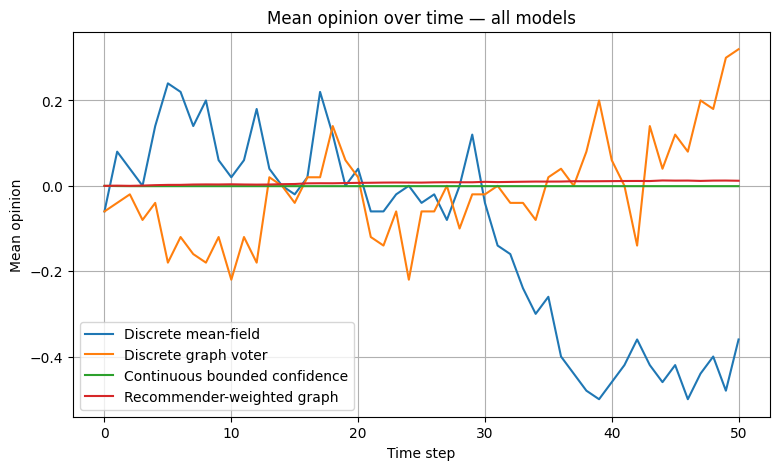

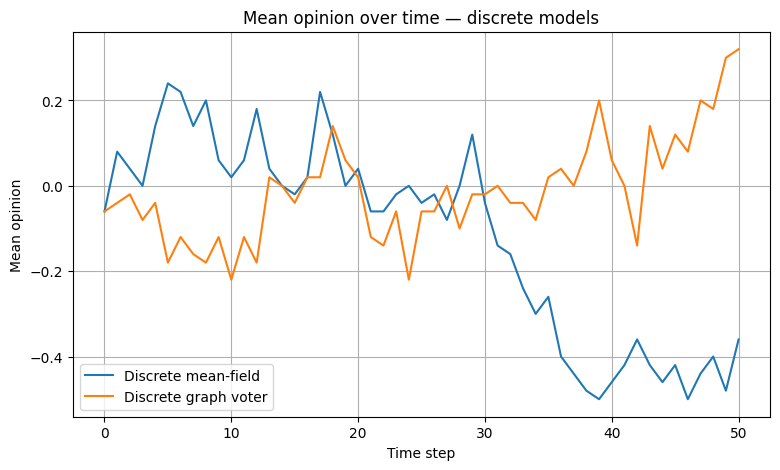

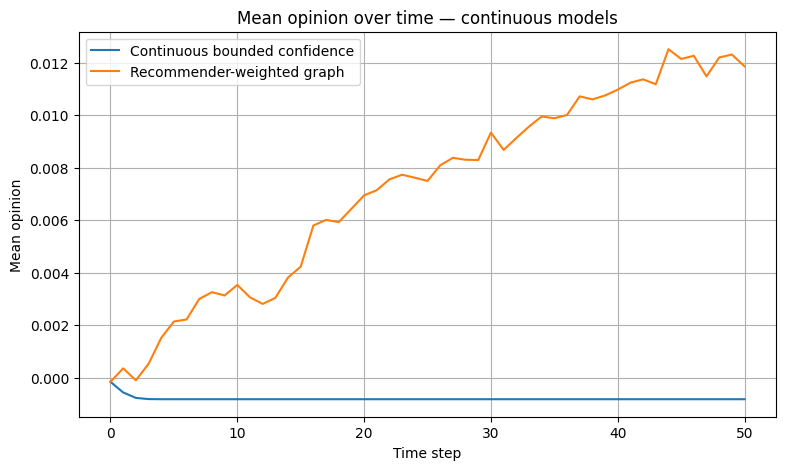

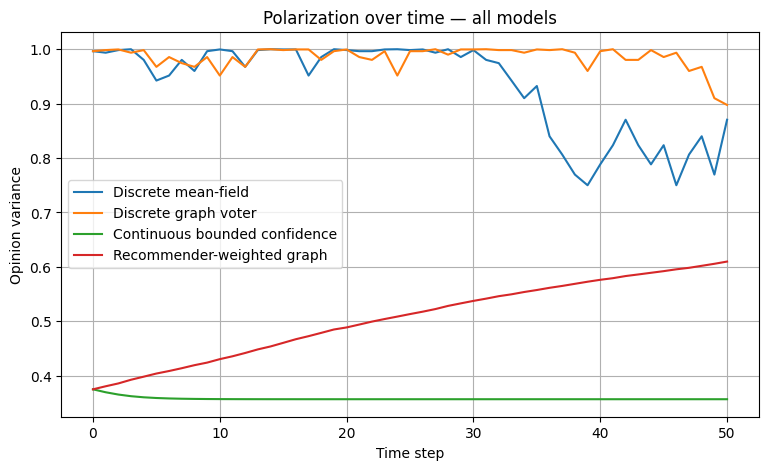

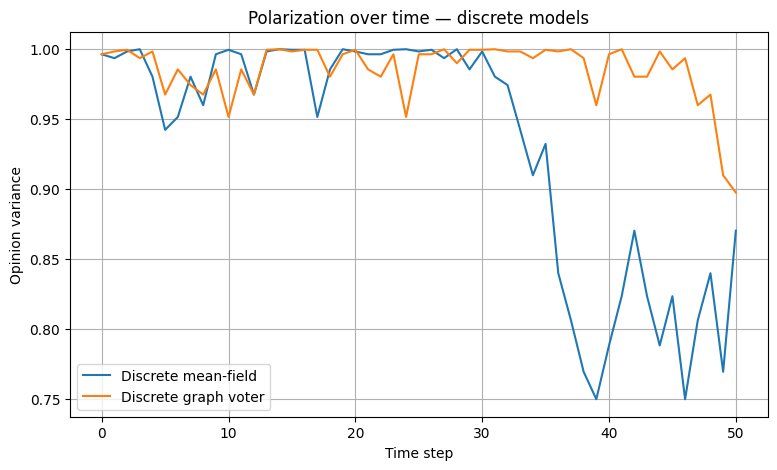

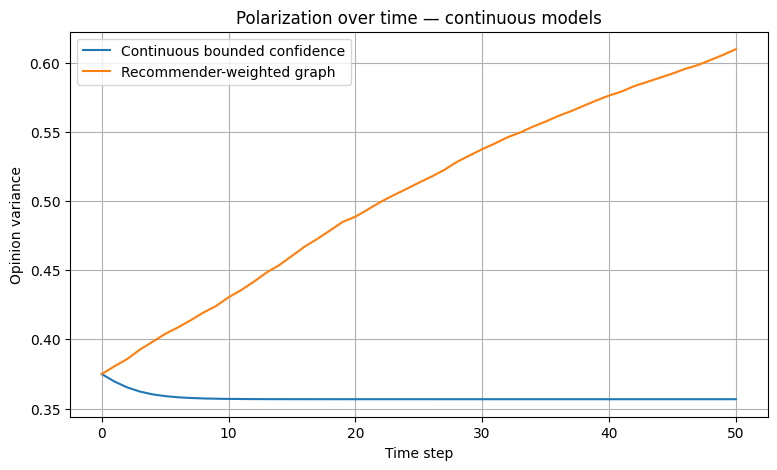

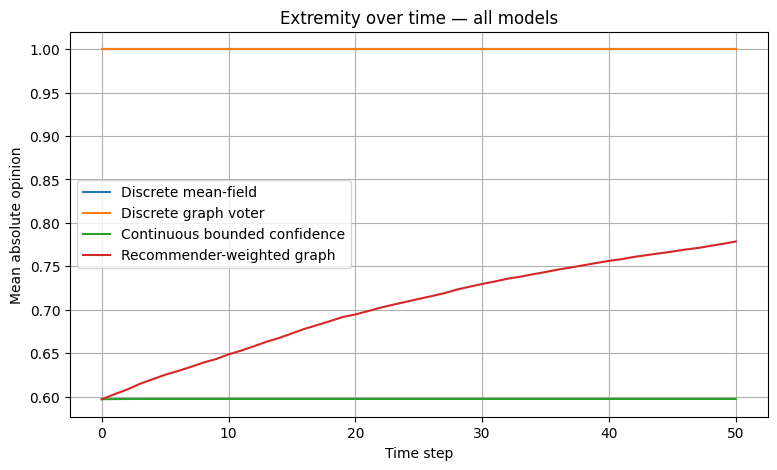

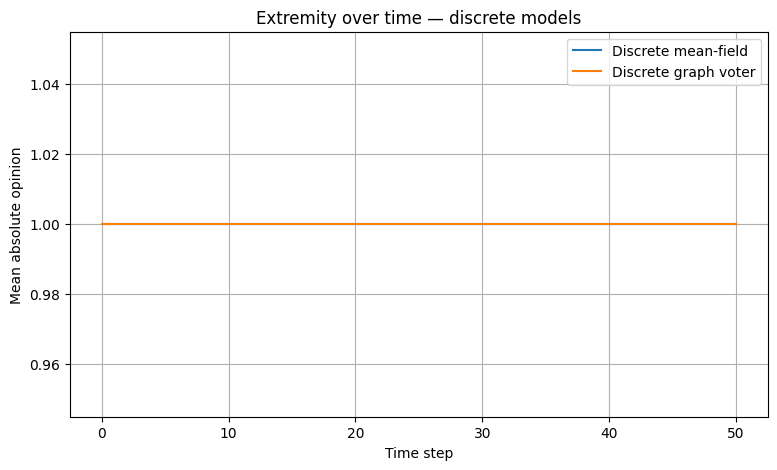

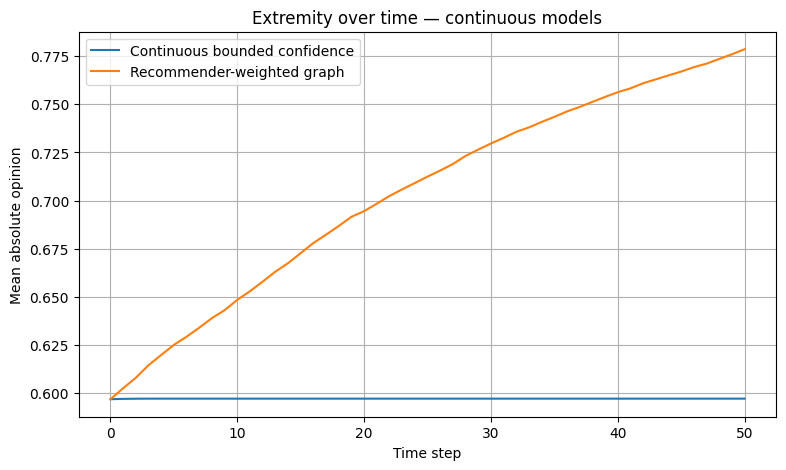

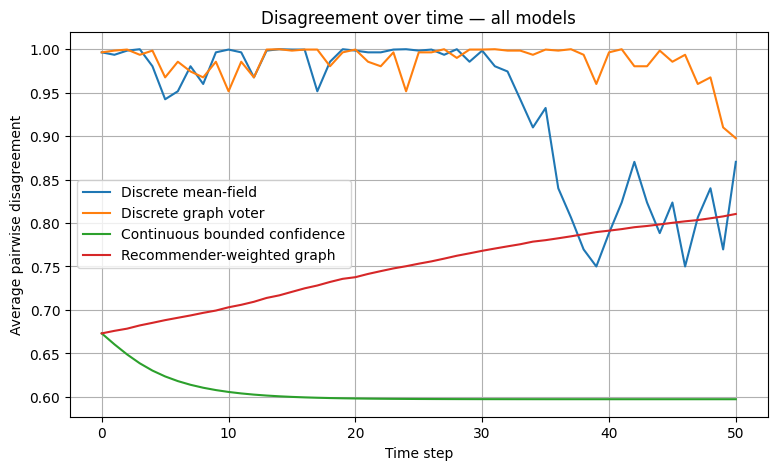

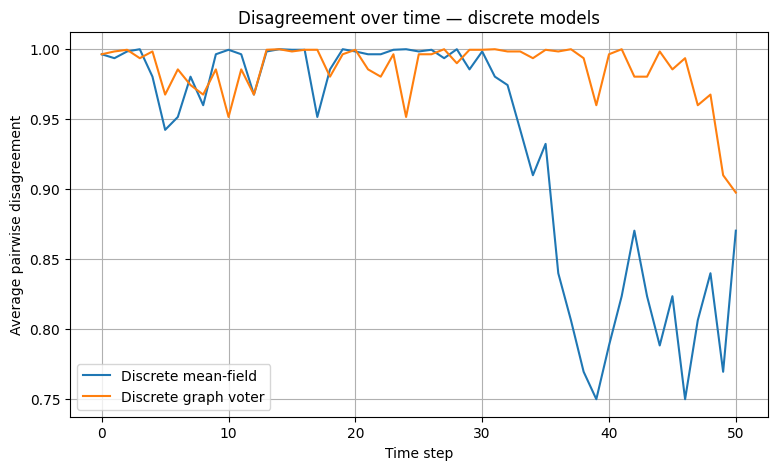

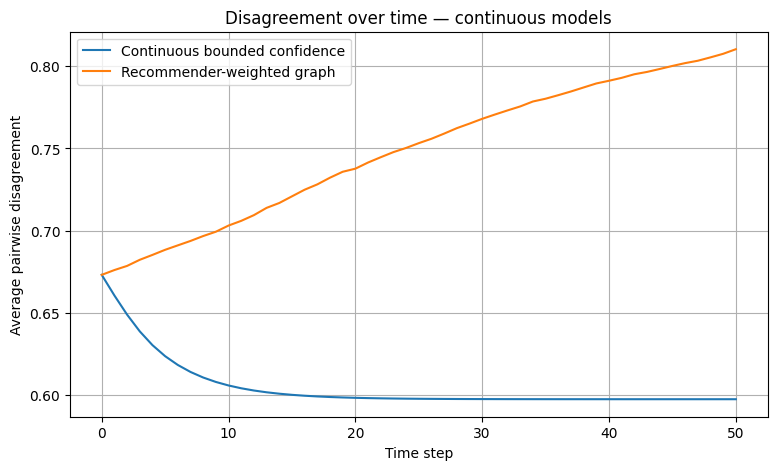

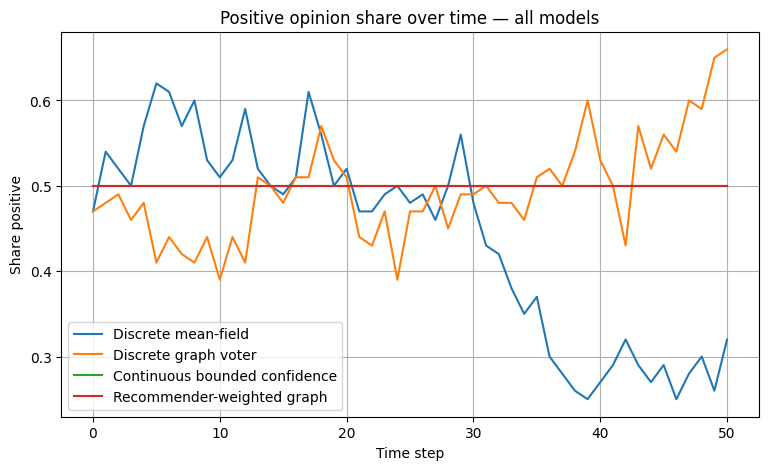

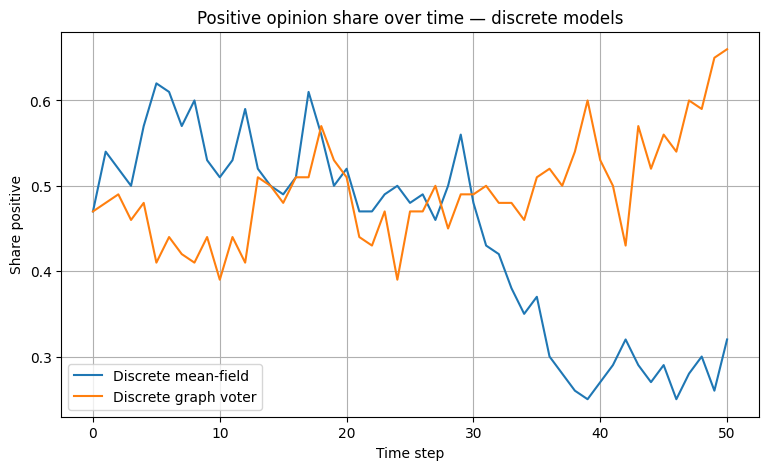

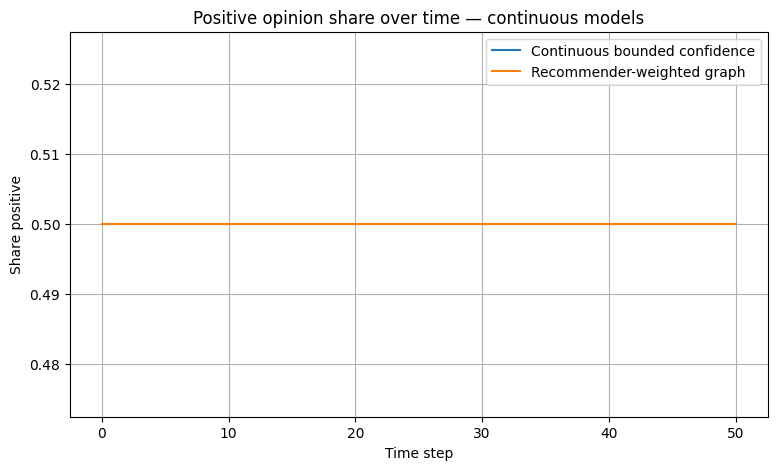

In [13]:
plot_metric_together_and_separate(
    model_runs,
    mean_opinion,
    "Mean opinion",
    "Mean opinion over time"
)

plot_metric_together_and_separate(
    model_runs,
    opinion_variance,
    "Opinion variance",
    "Polarization over time"
)

plot_metric_together_and_separate(
    model_runs,
    mean_absolute_opinion,
    "Mean absolute opinion",
    "Extremity over time"
)

plot_metric_together_and_separate(
    model_runs,
    disagreement_score,
    "Average pairwise disagreement",
    "Disagreement over time"
)

plot_metric_together_and_separate(
    model_runs,
    positive_share,
    "Share positive",
    "Positive opinion share over time"
)

## 13. Initial vs final distributions

These plots are especially important because mean opinion can hide polarization.

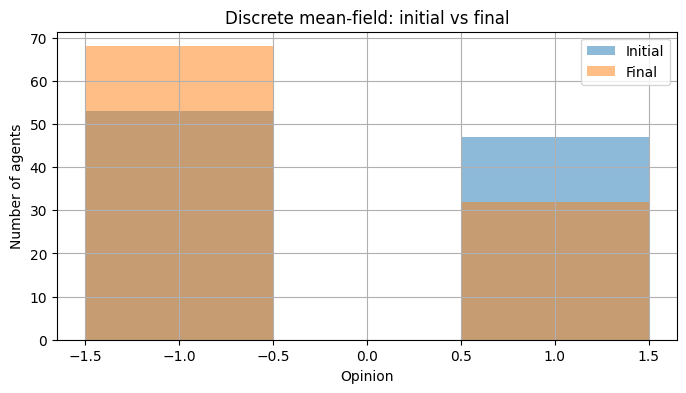

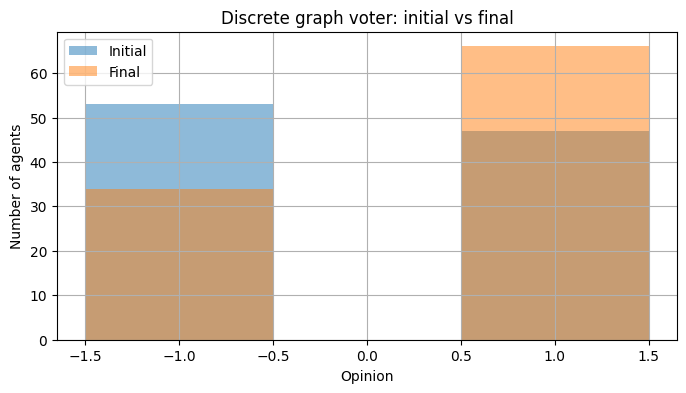

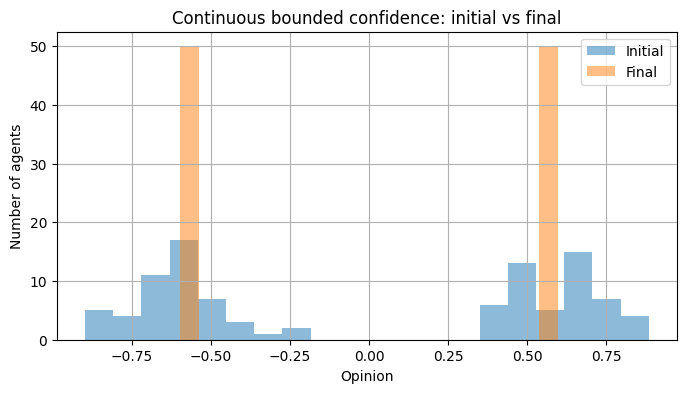

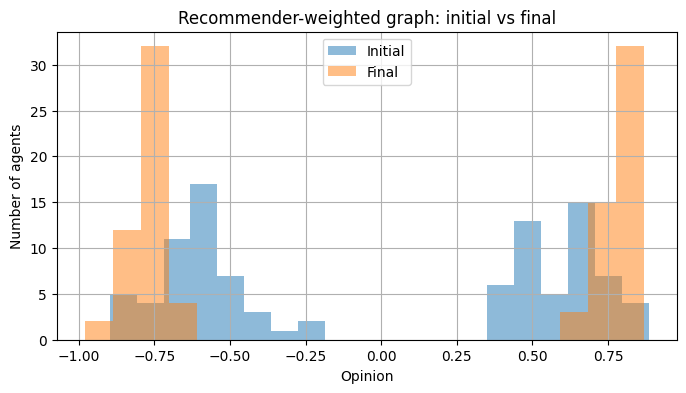

In [14]:
for run in model_runs:
    bins = 20 if run["opinion_type"] == "continuous" else [-1.5, -0.5, 0.5, 1.5]
    plot_initial_final_distribution(
        run["history"],
        f"{run['label']}: initial vs final",
        bins=bins
    )

## 14. Summary tables

In [15]:
def summarize_model(history, model_name, model_type, structure, opinion_type):
    final = history[-1]
    return {
        "model": model_name,
        "type": model_type,
        "structure": structure,
        "opinion_type": opinion_type,
        "final_mean": np.mean(final),
        "final_variance": np.var(final),
        "final_extremity": np.mean(np.abs(final)),
        "final_positive_share": np.mean(final > 0),
        "final_disagreement": disagreement_score(history)[-1],
        "min_opinion": np.min(final),
        "max_opinion": np.max(final),
        "discrete_consensus": reached_discrete_consensus(history) if opinion_type == "discrete" else None,
        "continuous_consensus": reached_continuous_consensus(history) if opinion_type == "continuous" else None
    }


results = []
for run in model_runs:
    results.append(
        summarize_model(
            history=run["history"],
            model_name=run["label"],
            model_type=f"{run['structure']}, {run['opinion_type']}",
            structure=run["structure"],
            opinion_type=run["opinion_type"]
        )
    )

results_df = pd.DataFrame(results)
results_df

,model,type,structure,opinion_type,final_mean,final_variance,final_extremity,final_positive_share,final_disagreement,min_opinion,max_opinion,discrete_consensus,continuous_consensus
0,Discrete mean-field,"non-graph, discrete",non-graph,discrete,-0.360000,0.870400,1.000000,0.32,0.870400,-1.000000,1.000000,False,None
1,Discrete graph voter,"graph, discrete",graph,discrete,0.320000,0.897600,1.000000,0.66,0.897600,-1.000000,1.000000,False,None
2,Continuous bounded confidence,"non-graph, continuous",non-graph,continuous,-0.000825,0.356719,0.597260,0.50,0.597261,-0.598089,0.596439,None,False
3,Recommender-weighted graph,"graph, continuous",graph,continuous,0.011855,0.609733,0.778582,0.50,0.810436,-0.979181,0.868821,None,False


## 15. Recommender algorithm comparison

This experiment keeps the same graph, initial opinions, and agent traits, but changes the recommendation algorithm.

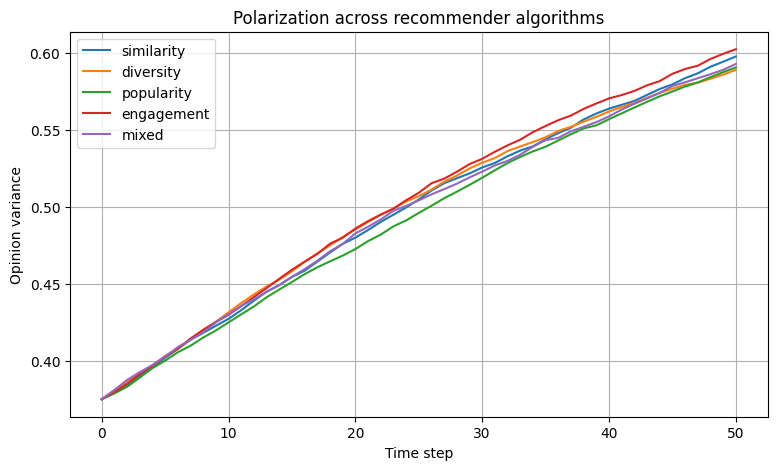

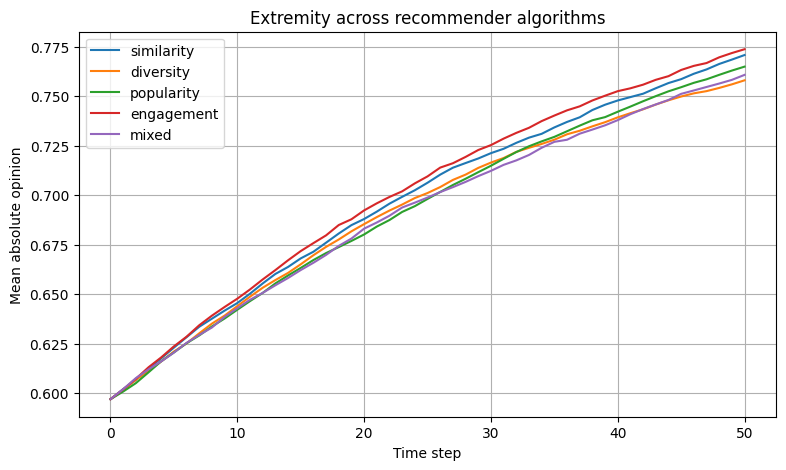

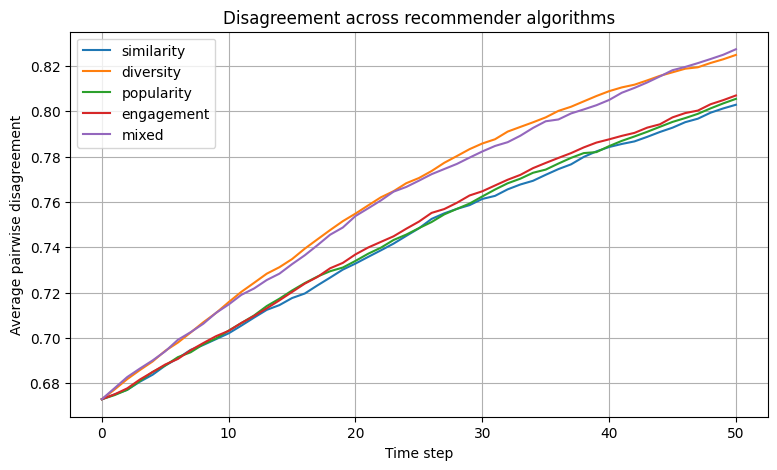

In [16]:
algorithms = ["similarity", "diversity", "popularity", "engagement", "mixed"]

# Reset seed so algorithm comparison is reproducible.
np.random.seed(123)

algorithm_histories = {}

for alg in algorithms:
    algorithm_histories[alg] = run_recommender_weighted_graph_human(
        G=G,
        s0=s0_continuous,
        T=T,
        traits=traits,
        mu=mu,
        epsilon=epsilon,
        beta=beta,
        algorithm=alg,
        amplification=0.12,
        exploration=0.05,
        noise_std=0.005,
        anchor_strength=0.05
    )

plot_algorithm_metric(
    algorithm_histories,
    opinion_variance,
    "Opinion variance",
    "Polarization across recommender algorithms"
)

plot_algorithm_metric(
    algorithm_histories,
    mean_absolute_opinion,
    "Mean absolute opinion",
    "Extremity across recommender algorithms"
)

plot_algorithm_metric(
    algorithm_histories,
    disagreement_score,
    "Average pairwise disagreement",
    "Disagreement across recommender algorithms"
)

In [17]:
algorithm_results = []
for alg, history in algorithm_histories.items():
    algorithm_results.append(
        summarize_model(
            history=history,
            model_name=alg,
            model_type="recommender algorithm",
            structure="graph",
            opinion_type="continuous"
        )
    )

algorithm_results_df = pd.DataFrame(algorithm_results)
algorithm_results_df

,model,type,structure,opinion_type,final_mean,final_variance,final_extremity,final_positive_share,final_disagreement,min_opinion,max_opinion,discrete_consensus,continuous_consensus
0,similarity,recommender algorithm,graph,continuous,0.013743,0.597846,0.770853,0.5,0.802897,-0.947313,0.877433,None,False
1,diversity,recommender algorithm,graph,continuous,0.012538,0.589100,0.758077,0.5,0.824878,-0.935908,0.933379,None,False
2,popularity,recommender algorithm,graph,continuous,0.006996,0.590707,0.764989,0.5,0.805492,-0.963288,0.874215,None,False
3,engagement,recommender algorithm,graph,continuous,0.011990,0.602576,0.773785,0.5,0.806994,-0.957497,0.861575,None,False
4,mixed,recommender algorithm,graph,continuous,0.014487,0.592970,0.760825,0.5,0.827385,-0.952745,0.937714,None,False


## 16. Optional: similarity-bias parameter sweep

This tests whether stronger similarity bias changes polarization.

\[
eta = 0
\]
means little similarity bias, while larger \(eta\) means stronger preference for similar opinions.

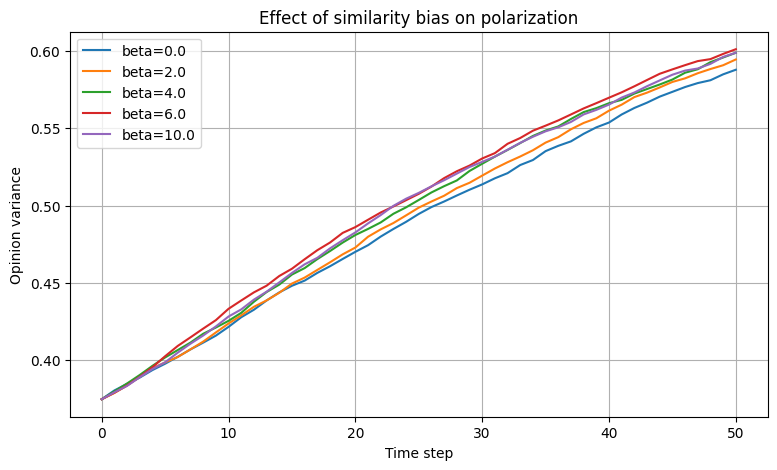

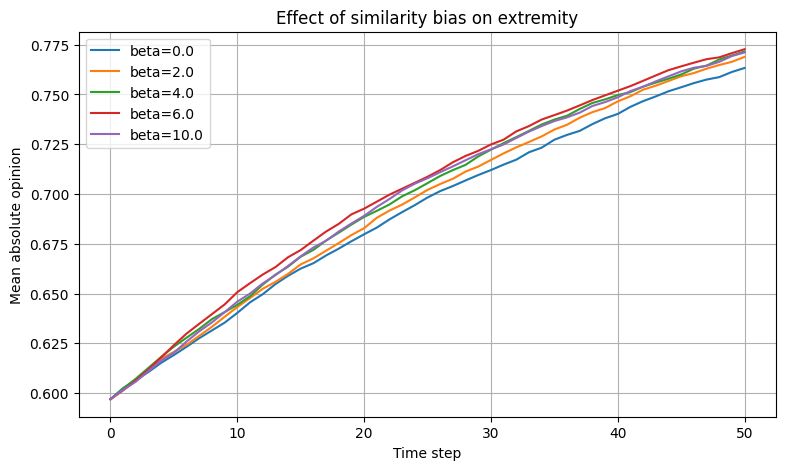

In [18]:
beta_values = [0.0, 2.0, 4.0, 6.0, 10.0]

np.random.seed(456)
beta_histories = {}

for b in beta_values:
    beta_histories[b] = run_recommender_weighted_graph_human(
        G=G,
        s0=s0_continuous,
        T=T,
        traits=traits,
        mu=mu,
        epsilon=epsilon,
        beta=b,
        algorithm="similarity",
        amplification=0.12,
        exploration=0.05,
        noise_std=0.005,
        anchor_strength=0.05
    )

plt.figure(figsize=(9, 5))
for b, history in beta_histories.items():
    plt.plot(opinion_variance(history), label=f"beta={b}")
plt.xlabel("Time step")
plt.ylabel("Opinion variance")
plt.title("Effect of similarity bias on polarization")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
for b, history in beta_histories.items():
    plt.plot(mean_absolute_opinion(history), label=f"beta={b}")
plt.xlabel("Time step")
plt.ylabel("Mean absolute opinion")
plt.title("Effect of similarity bias on extremity")
plt.legend()
plt.grid(True)
plt.show()

## 17. Optional: initial distribution comparison

This connects to the question of sampling from non-normal distributions. The same recommender model is run with uniform, normal, and bimodal initial opinions.

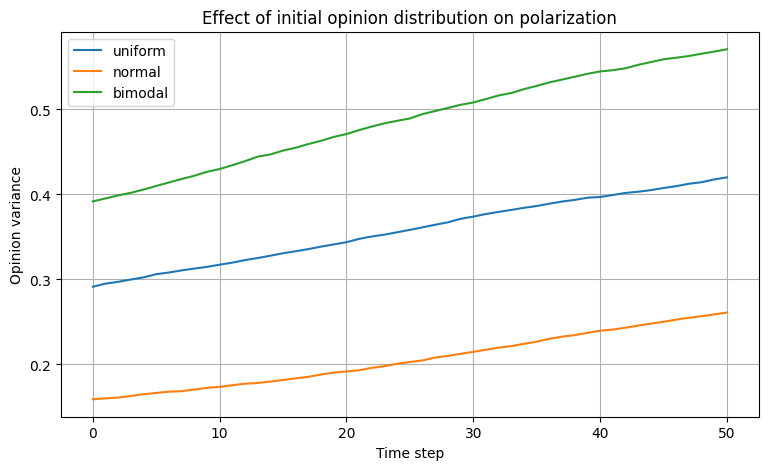

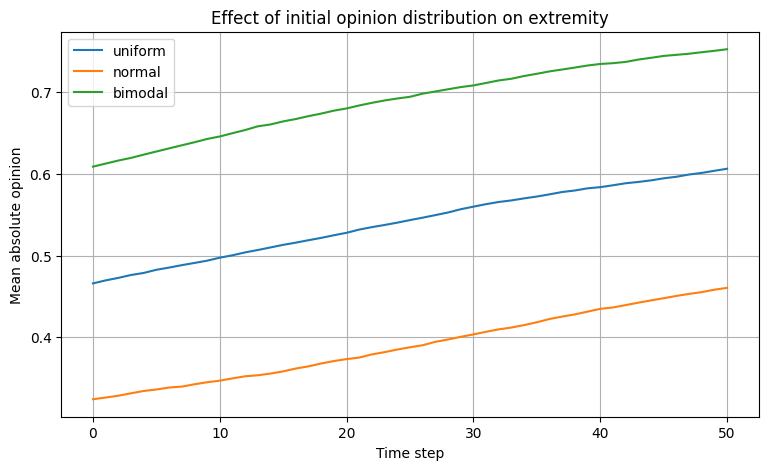

In [19]:
distributions = ["uniform", "normal", "bimodal"]

distribution_histories = {}

np.random.seed(789)
for dist in distributions:
    s0_dist = initialize_continuous_opinions(N, distribution=dist)
    traits_dist = initialize_agent_traits(N)

    distribution_histories[dist] = run_recommender_weighted_graph_human(
        G=G,
        s0=s0_dist,
        T=T,
        traits=traits_dist,
        mu=mu,
        epsilon=epsilon,
        beta=beta,
        algorithm="engagement",
        amplification=0.12,
        exploration=0.05,
        noise_std=0.005,
        anchor_strength=0.05
    )

plot_algorithm_metric(
    distribution_histories,
    opinion_variance,
    "Opinion variance",
    "Effect of initial opinion distribution on polarization"
)

plot_algorithm_metric(
    distribution_histories,
    mean_absolute_opinion,
    "Mean absolute opinion",
    "Effect of initial opinion distribution on extremity"
)

## 18. Methods wording you can reuse

This project compares opinion dynamics models across two dimensions: opinion space and interaction structure. Opinion space was modeled as either discrete, \(s_i(t)\in\{-1,+1\}\), or continuous, \(s_i(t)\in[-1,1]\). Interaction structure was modeled as either non-graph-based or graph-based. The non-graph models represent population-level or confidence-based influence without explicit edges, while the graph-based models restrict influence to neighboring nodes in a social network.

The main model extends continuous bounded-confidence dynamics with recommender-system exposure. In this model, the graph defines possible interactions, while the recommender algorithm assigns dynamic exposure probabilities to neighbors. Agents also have heterogeneous behavioral traits, including susceptibility, stubbornness, activity level, and extremity bias. This allows the model to represent differences in how frequently agents update, how strongly they respond to influence, how much they resist opinion change, and how likely they are to move toward stronger versions of their current opinions.

The recommender model was tested under several simulated recommendation strategies: similarity-based, diversity-based, popularity-based, engagement-based, and mixed recommendation. This allows the simulation to compare how different algorithmic exposure mechanisms affect polarization, extremity, and disagreement over time.

A fully data-driven recommender model is left as a future extension. In such a model, the weights \(w_{ij}(t)\) could be learned from empirical engagement data such as clicks, likes, viewing time, or interaction histories rather than being generated from theoretical similarity or popularity functions.

In [21]:
# ============================================================
# Epsilon sensitivity analysis for continuous bounded confidence
# ============================================================

epsilon_values = [0.10, 0.20, 0.30, 0.40, 0.60]

epsilon_histories = {}

for eps in epsilon_values:
    epsilon_histories[eps] = run_continuous_bounded_confidence_non_graph(
        s0=s0_continuous,
        T=T,
        mu=0.25,
        epsilon=eps
    )

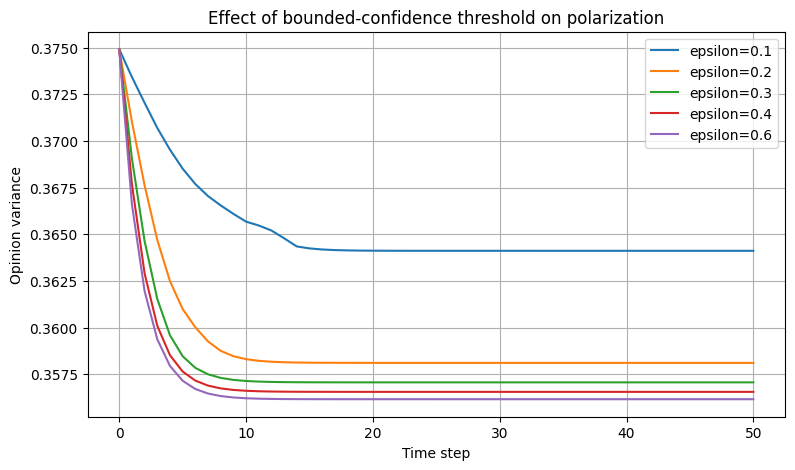

In [22]:
plt.figure(figsize=(9, 5))

for eps, history in epsilon_histories.items():
    plt.plot(opinion_variance(history), label=f"epsilon={eps}")

plt.xlabel("Time step")
plt.ylabel("Opinion variance")
plt.title("Effect of bounded-confidence threshold on polarization")
plt.legend()
plt.grid(True)
plt.show()

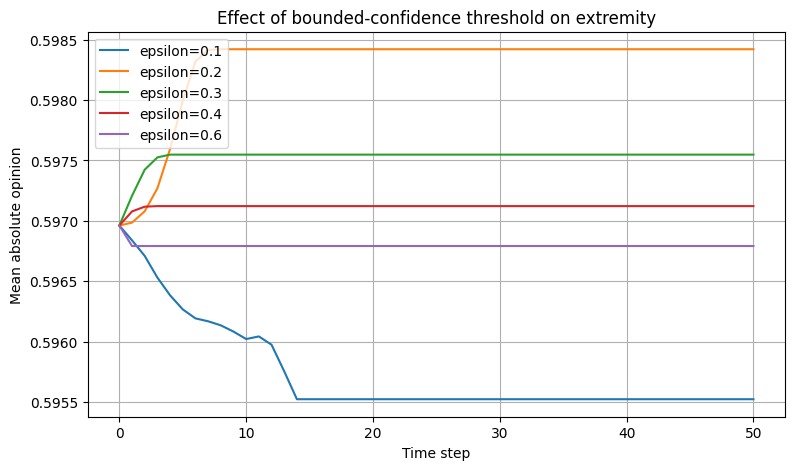

In [23]:
plt.figure(figsize=(9, 5))

for eps, history in epsilon_histories.items():
    plt.plot(mean_absolute_opinion(history), label=f"epsilon={eps}")

plt.xlabel("Time step")
plt.ylabel("Mean absolute opinion")
plt.title("Effect of bounded-confidence threshold on extremity")
plt.legend()
plt.grid(True)
plt.show()

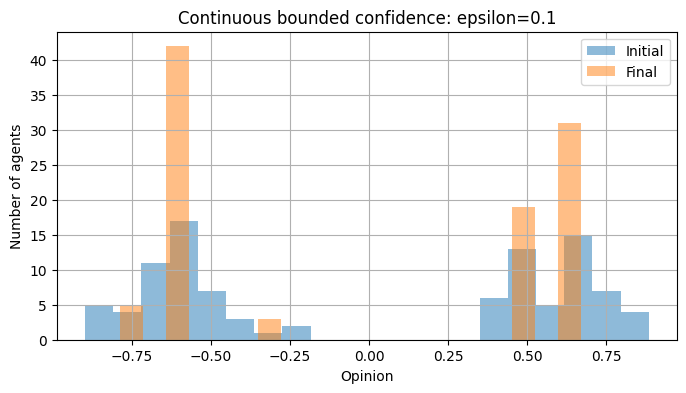

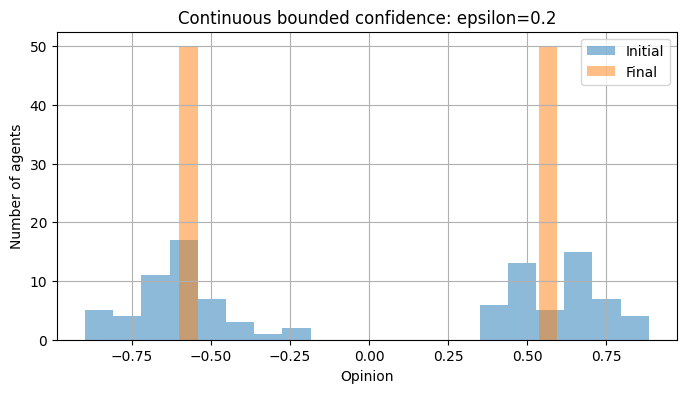

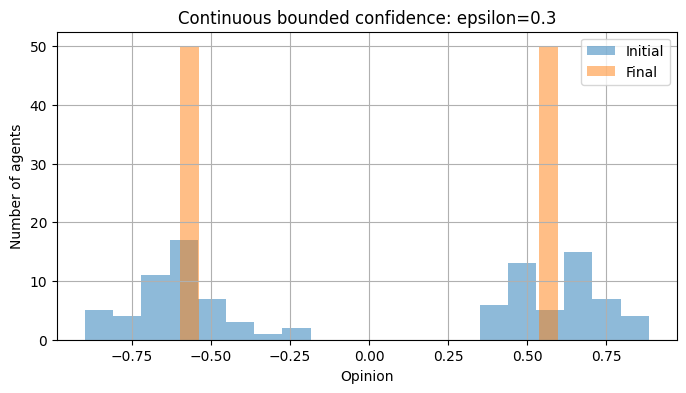

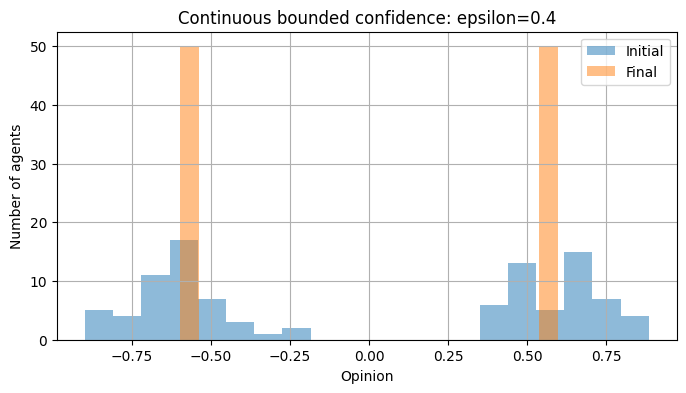

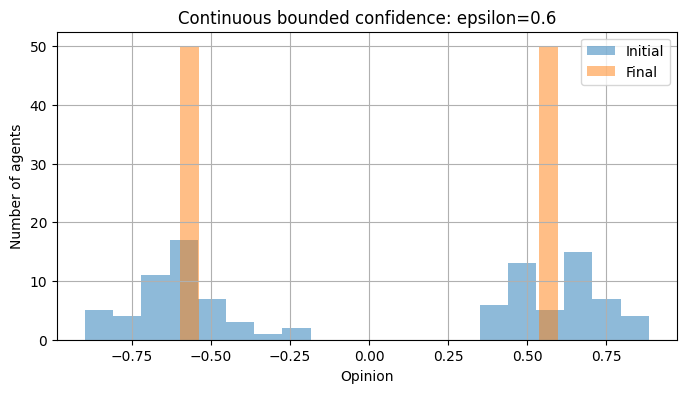

In [24]:
for eps, history in epsilon_histories.items():
    plot_initial_final_distribution(
        history,
        f"Continuous bounded confidence: epsilon={eps}"
    )